# HypeGuard — Notebook 03: Model Validation (Offline Holdout)
**Pre-requisite:** Run `02_Model_Training.ipynb` first — model `.pkl` files must exist.

**What this notebook does:**
1. Loads trained models from `../backend/models/`
2. Loads holdout data from `../data/training_val.csv`
3. Computes offline validation pass rates and score distributions
4. Produces the final validation chart for your report (`../data/model_validation.png`)
5. Simulates API-style output from a validation sample (without live scraping)

In [13]:
# ═══════════════════════════════════════════════════════════
# CELL 1 — LOAD MODELS + OFFLINE VALIDATION DATA
# ═══════════════════════════════════════════════════════════
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':'#0f0f0f','axes.facecolor':'#1a1a1a',
    'text.color':'white','axes.labelcolor':'white',
    'xtick.color':'white','ytick.color':'white',
    'axes.edgecolor':'#444','grid.color':'#333',
    'font.family':'monospace',
})
RED=   '#ef4444'; GREEN='#22c55e'; AMBER='#f59e0b'
ORANGE='#f97316'; GRAY= '#6b7280'; BLUE= '#3b82f6'

print('Loading models and validation dataset...')

with open('../backend/models/random_forest.pkl', 'rb') as f:
    rf_bundle = pickle.load(f)
with open('../backend/models/isolation_forest.pkl', 'rb') as f:
    iso_bundle = pickle.load(f)

rf             = rf_bundle['model']
FEATURES_FINAL = rf_bundle['feature_order']
LABEL_MAP      = rf_bundle['label_map']
LABEL_MAP_INV  = rf_bundle['label_map_inv']
iso            = iso_bundle['model']
scaler         = iso_bundle['scaler']

VAL_PATH = '../data/training_val.csv'
if not os.path.exists(VAL_PATH):
    raise FileNotFoundError(f'Missing validation file: {VAL_PATH}')
val_df = pd.read_csv(VAL_PATH)

missing = [c for c in FEATURES_FINAL if c not in val_df.columns]
if missing:
    raise ValueError(f'Validation CSV missing features: {missing}')

if 'pseudo_label' not in val_df.columns:
    raise ValueError('Validation CSV must contain pseudo_label column')

hype_class_idx = list(rf.classes_).index(LABEL_MAP['HYPE']) if LABEL_MAP['HYPE'] in rf.classes_ else None

def predict_from_row(row: pd.Series) -> dict:
    x = np.array([[float(row.get(f, 0.0)) for f in FEATURES_FINAL]])
    x_scaled = scaler.transform(x)
    iso_raw = iso.score_samples(x_scaled)[0]
    anomaly_score = float(np.clip(1 - (iso_raw + 0.5), 0, 1))

    proba = rf.predict_proba(x)[0]
    predicted_cls = int(rf.classes_[np.argmax(proba)])
    rf_label = LABEL_MAP_INV.get(predicted_cls, 'NEUTRAL')

    hype_prob = float(proba[hype_class_idx]) if hype_class_idx is not None else 0.4
    hype_score = round(min(hype_prob * 70 + anomaly_score * 30, 100), 1)

    if hype_score >= 86:
        final_label = 'PUMP_ALERT'
    elif hype_score >= 61:
        final_label = 'HYPE'
    elif hype_score >= 31:
        final_label = 'NEUTRAL'
    else:
        final_label = 'ORGANIC'

    return {
        'ticker': row.get('ticker', 'UNKNOWN'),
        'hype_score': hype_score,
        'final_label': final_label,
        'rf_label': rf_label,
        'anomaly_score': round(anomaly_score, 3),
        'hype_prob_rf': round(hype_prob * 100, 1),
        'proba_dict': {LABEL_MAP_INV.get(int(rf.classes_[i]), '?'): round(float(p), 3) for i, p in enumerate(proba)},
        'pseudo_label': row.get('pseudo_label', 'NEUTRAL'),
        'rvol': float(row.get('rvol', 0.0)),
        'rsi_14': float(row.get('rsi_14', 0.0)),
        'news_count': int(row.get('total_headlines', row.get('news_count', 0))),
    }

print(f'✓ Random Forest loaded   | features={len(FEATURES_FINAL)} | classes={rf.classes_.tolist()}')
print('✓ Isolation Forest loaded | scaler fitted')
print(f'✓ Validation rows loaded  | {len(val_df)} rows')
print('\n✓ predict_from_row() ready')

Loading models and validation dataset...
✓ Random Forest loaded   | features=15 | classes=[0, 1, 2, 3]
✓ Isolation Forest loaded | scaler fitted
✓ Validation rows loaded  | 3 rows

✓ predict_from_row() ready


In [14]:
# ═══════════════════════════════════════════════════════════
# CELL 2 — OFFLINE VALIDATION ON training_val.csv
# Pass condition: HYPE rows > 55%, ORGANIC/NEUTRAL rows < 45%
# ═══════════════════════════════════════════════════════════

HIGH_THRESHOLD = 55
LOW_THRESHOLD  = 45

print('Running offline validation on holdout set...')
print('=' * 80)

results = []
valid_labels = {'HYPE', 'ORGANIC', 'NEUTRAL'}
eval_df = val_df[val_df['pseudo_label'].isin(valid_labels)].copy()

for _, row in eval_df.iterrows():
    r = predict_from_row(row)

    true_label = r['pseudo_label']
    if true_label == 'HYPE':
        exp_range = 'HIGH'
        passed = r['hype_score'] > HIGH_THRESHOLD
    else:
        exp_range = 'LOW'
        passed = r['hype_score'] < LOW_THRESHOLD

    r['expected_range'] = exp_range
    r['passed'] = bool(passed)
    results.append(r)

results_df = pd.DataFrame(results)

total = len(results_df)
passed = int(results_df['passed'].sum()) if total > 0 else 0
acc = (passed / total) if total > 0 else 0.0

print(f'Evaluated rows: {total}')
print(f'Pass rows     : {passed}/{total} ({acc:.1%})')

if total > 0:
    by_label = results_df.groupby('pseudo_label')['passed'].mean().sort_index()
    print('\nPass rate by pseudo_label:')
    for lbl, v in by_label.items():
        print(f'  {lbl:10s}: {v:.1%}')

    print('\nSample predictions:')
    sample_cols = ['ticker', 'pseudo_label', 'hype_score', 'final_label', 'anomaly_score', 'rvol', 'rsi_14', 'passed']
    print(results_df[sample_cols].head(15).to_string(index=False))

Running offline validation on holdout set...
Evaluated rows: 3
Pass rows     : 3/3 (100.0%)

Pass rate by pseudo_label:
  HYPE      : 100.0%
  NEUTRAL   : 100.0%
  ORGANIC   : 100.0%

Sample predictions:
ticker pseudo_label  hype_score final_label  anomaly_score  rvol  rsi_14  passed
  AAPL      ORGANIC        37.9     NEUTRAL          0.967 0.742   59.73    True
   GME         HYPE        63.6        HYPE          1.000 0.810   82.41    True
 BRK-B      NEUTRAL        40.9     NEUTRAL          0.985 0.843   29.17    True


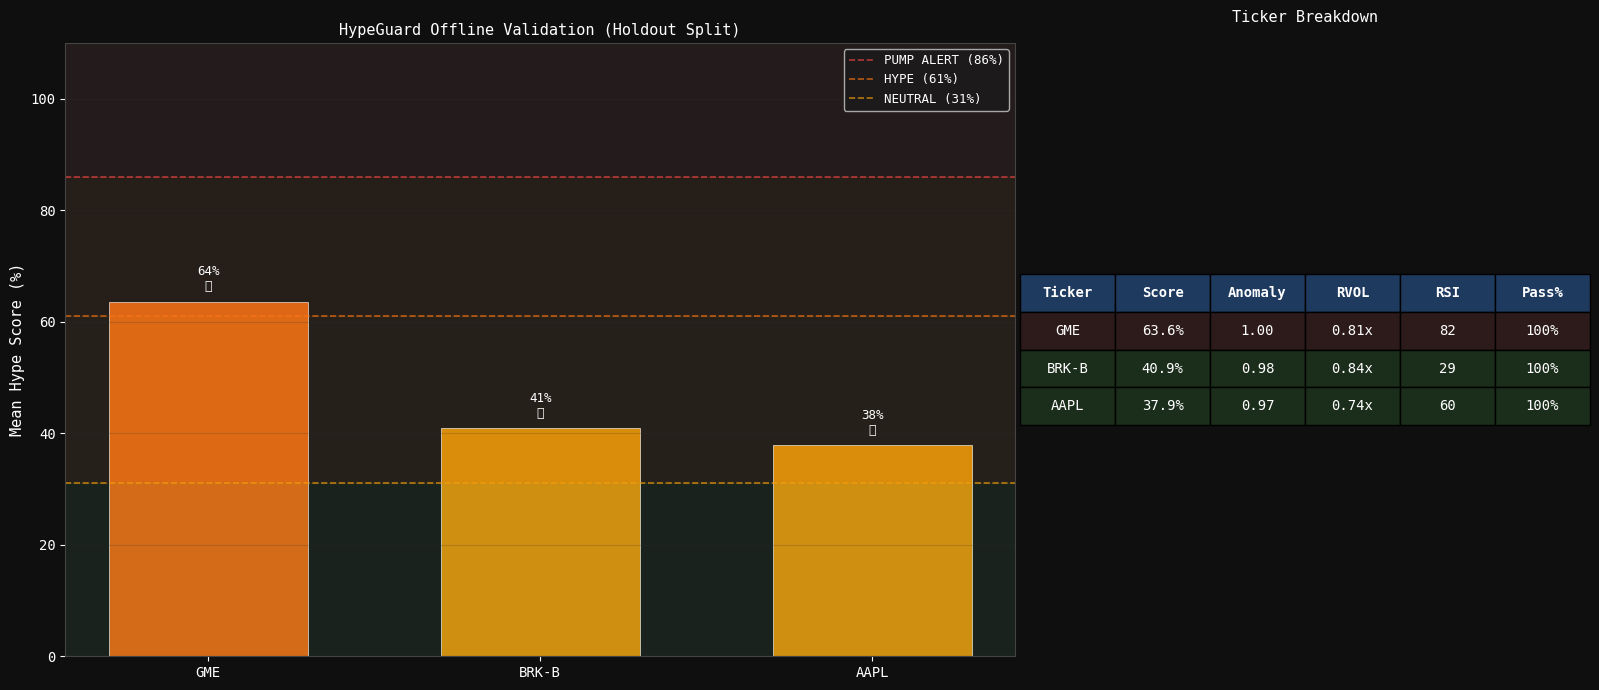

✓ Saved: ../data/model_validation.png


In [15]:
# ═══════════════════════════════════════════════════════════
# CELL 3 — VALIDATION CHART (OFFLINE HOLDOUT)
# ═══════════════════════════════════════════════════════════

if not results:
    print('No results to chart. Check Cell 2 errors.')
else:
    results_df = pd.DataFrame(results)

    # Aggregate per ticker for cleaner chart
    agg = results_df.groupby('ticker').agg(
        hype_score=('hype_score', 'mean'),
        anomaly_score=('anomaly_score', 'mean'),
        rvol=('rvol', 'mean'),
        rsi_14=('rsi_14', 'mean'),
        pass_rate=('passed', 'mean'),
    ).reset_index().sort_values('hype_score', ascending=False)

    fig, (ax_main, ax_table) = plt.subplots(
        1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [2, 1]}
    )

    bar_colors = []
    for s in agg['hype_score']:
        if s >= 86:
            bar_colors.append(RED)
        elif s >= 61:
            bar_colors.append(ORANGE)
        elif s >= 31:
            bar_colors.append(AMBER)
        else:
            bar_colors.append(GREEN)

    bars = ax_main.bar(
        agg['ticker'], agg['hype_score'], color=bar_colors, alpha=0.88, width=0.6,
        edgecolor='white', linewidth=0.5
    )

    ax_main.axhline(86, color=RED, linestyle='--', linewidth=1.2, alpha=0.7, label='PUMP ALERT (86%)')
    ax_main.axhline(61, color=ORANGE, linestyle='--', linewidth=1.2, alpha=0.7, label='HYPE (61%)')
    ax_main.axhline(31, color=AMBER, linestyle='--', linewidth=1.2, alpha=0.7, label='NEUTRAL (31%)')
    ax_main.axhline(0, color=GREEN, linestyle='-', linewidth=0.5, alpha=0.3)

    for bar, row in zip(bars, agg.itertuples()):
        icon = '✅' if row.pass_rate >= 0.5 else '⚠️'
        ax_main.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.5,
            f'{row.hype_score:.0f}%\n{icon}',
            ha='center', va='bottom', fontsize=9, color='white',
        )

    ax_main.set_ylim(0, 110)
    ax_main.set_ylabel('Mean Hype Score (%)', fontsize=11)
    ax_main.set_title('HypeGuard Offline Validation (Holdout Split)', fontsize=11)
    ax_main.legend(loc='upper right', fontsize=9)
    ax_main.grid(axis='y', alpha=0.2)

    ax_main.axhspan(86, 110, alpha=0.05, color=RED)
    ax_main.axhspan(61, 86, alpha=0.05, color=ORANGE)
    ax_main.axhspan(31, 61, alpha=0.05, color=AMBER)
    ax_main.axhspan(0, 31, alpha=0.05, color=GREEN)

    ax_table.axis('off')
    table_data = []
    for _, row in agg.iterrows():
        table_data.append([
            row['ticker'],
            f"{row['hype_score']:.1f}%",
            f"{row['anomaly_score']:.2f}",
            f"{row['rvol']:.2f}x",
            f"{row['rsi_14']:.0f}",
            f"{row['pass_rate']*100:.0f}%",
        ])

    table = ax_table.table(
        cellText=table_data,
        colLabels=['Ticker', 'Score', 'Anomaly', 'RVOL', 'RSI', 'Pass%'],
        loc='center', cellLoc='center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 2.0)

    for j in range(6):
        table[(0, j)].set_facecolor('#1e3a5f')
        table[(0, j)].set_text_props(color='white', fontweight='bold')

    for i, row in enumerate(agg.itertuples()):
        row_color = '#2d1b1b' if row.hype_score > 60 else '#1b2d1b'
        for j in range(6):
            table[(i + 1, j)].set_facecolor(row_color)
            table[(i + 1, j)].set_text_props(color='white')

    ax_table.set_title('Ticker Breakdown', fontsize=11, pad=15)

    plt.tight_layout()
    plt.savefig('../data/model_validation.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()
    print('✓ Saved: ../data/model_validation.png')

In [16]:
# ═══════════════════════════════════════════════════════════
# CELL 4 — SIMULATE API RESPONSE FROM HOLDOUT ROW
# Offline simulation using one validation sample.
# ═══════════════════════════════════════════════════════════

if val_df.empty:
    print('Validation dataframe is empty. Run Cell 1 first.')
else:
    # Pick the row with highest predicted hype score for a realistic risk example
    scored = []
    for idx, row in val_df.iterrows():
        pred = predict_from_row(row)
        pred['_idx'] = idx
        scored.append(pred)

    scored_df = pd.DataFrame(scored).sort_values('hype_score', ascending=False)
    top = scored_df.iloc[0]
    src = val_df.iloc[int(top['_idx'])]

    TICKER = str(top['ticker'])
    AMOUNT = 5000
    CURRENCY = 'INR'

    hype_score = float(top['hype_score'])
    anomaly = float(top['anomaly_score'])
    label = str(top['final_label'])

    if hype_score >= 86:
        action, pct, days = 'AVOID', 0, 7
        advice_reason = 'Extreme manipulation risk. Avoid until volume normalizes.'
    elif hype_score >= 61:
        action, pct, days = 'WAIT', 20, 4
        advice_reason = 'High hype detected. Deploy 20% as probe; hold remainder.'
    else:
        action, pct, days = 'BUY', 100, 0
        advice_reason = 'Low hype signal. Movement appears organic.'

    deploy_inr = AMOUNT * pct / 100
    deploy_usd = round(deploy_inr / 83.5, 2)

    print('═' * 60)
    print(f'  OFFLINE API SIMULATION: ticker={TICKER}, amount={AMOUNT}, currency={CURRENCY}')
    print('═' * 60)
    print(f'  pseudo_label      : {src.get("pseudo_label", "N/A")}')
    print(f'  rvol              : {float(src.get("rvol", 0.0)):.2f}x')
    print(f'  rsi_14            : {float(src.get("rsi_14", 0.0)):.1f}')
    print(f'  anomaly_score     : {anomaly:.3f}')
    print(f'  hype_score        : {hype_score:.1f}%')
    print(f'  final_label       : {label}')
    print(f'  action            : {action}')
    print(f'  deploy_now_pct    : {pct}%')
    print(f'  deploy_now_inr    : ₹{deploy_inr:,.0f}')
    print(f'  deploy_now_usd    : ${deploy_usd:,.2f}')
    print(f'  wait_days         : {days}')
    print(f'  reason            : {advice_reason}')

    print('\nFINAL JSON RESPONSE (schema-level):')
    print('{')
    print(f'  "ticker": "{TICKER}",')
    print(f'  "hype_score": {hype_score:.1f},')
    print(f'  "label": "{label}",')
    print(f'  "anomaly_score": {anomaly:.3f},')
    print('  "reasoning": [...],')
    print('  "investment_advice": {')
    print(f'    "action": "{action}",')
    print(f'    "deploy_now_pct": {pct},')
    print(f'    "deploy_now_inr": {deploy_inr:.2f},')
    print(f'    "deploy_now_usd": {deploy_usd:.2f},')
    print(f'    "wait_days": {days}')
    print('  }')
    print('}')

════════════════════════════════════════════════════════════
  OFFLINE API SIMULATION: ticker=GME, amount=5000, currency=INR
════════════════════════════════════════════════════════════
  pseudo_label      : HYPE
  rvol              : 0.81x
  rsi_14            : 82.4
  anomaly_score     : 1.000
  hype_score        : 63.6%
  final_label       : HYPE
  action            : WAIT
  deploy_now_pct    : 20%
  deploy_now_inr    : ₹1,000
  deploy_now_usd    : $11.98
  wait_days         : 4
  reason            : High hype detected. Deploy 20% as probe; hold remainder.

FINAL JSON RESPONSE (schema-level):
{
  "ticker": "GME",
  "hype_score": 63.6,
  "label": "HYPE",
  "anomaly_score": 1.000,
  "reasoning": [...],
  "investment_advice": {
    "action": "WAIT",
    "deploy_now_pct": 20,
    "deploy_now_inr": 1000.00,
    "deploy_now_usd": 11.98,
    "wait_days": 4
  }
}


In [17]:
# ═══════════════════════════════════════════════════════════
# CELL 5 — FINAL CHECKLIST (OFFLINE PIPELINE)
# ═══════════════════════════════════════════════════════════

import os

print('═' * 55)
print('  COMPLETE PROJECT HANDOFF CHECKLIST')
print('═' * 55)

checks = [
    ('../backend/models/random_forest.pkl',     'ML model file'),
    ('../backend/models/isolation_forest.pkl',  'Anomaly model file'),
    ('../data/training_data.csv',               'Full training dataset'),
    ('../data/training_train.csv',              'Train split'),
    ('../data/training_val.csv',                'Validation split'),
    ('../data/training_report.json',            'Split report'),
    ('../data/eda_feature_distributions.png',   'EDA chart A'),
    ('../data/eda_feature_variance.png',        'EDA chart B'),
    ('../data/eda_correlation_heatmap.png',     'EDA chart C'),
    ('../data/model_feature_importance.png',    'Model importance chart'),
    ('../data/model_validation.png',            'Validation chart'),
]

all_ok = True
for path, note in checks:
    exists = os.path.exists(path)
    icon = 'OK' if exists else 'MISSING'
    size = f'{os.path.getsize(path)/1024:.0f}KB' if exists else 'N/A'
    print(f'  [{icon:7s}] [{size:6s}] {note}')
    print(f'         {path}')
    if not exists:
        all_ok = False

print('\nQuick model sanity on validation split:')
if not val_df.empty:
    sample = val_df.head(min(5, len(val_df)))
    for _, row in sample.iterrows():
        pred = predict_from_row(row)
        print(f'  {pred["ticker"]:8s} | pseudo={pred["pseudo_label"]:12s} | score={pred["hype_score"]:5.1f}% | label={pred["final_label"]}')
else:
    print('  Validation split unavailable in memory. Run Cell 1.')

print()
if all_ok:
    print('  ALL REQUIRED ARTIFACTS PRESENT. Pipeline ready.')
    print('  Flow: Notebook 1 -> Notebook 2 -> Notebook 3')
else:
    print('  Some artifacts are missing. Re-run prior notebooks to regenerate.')

═══════════════════════════════════════════════════════
  COMPLETE PROJECT HANDOFF CHECKLIST
═══════════════════════════════════════════════════════
  [OK     ] [317KB ] ML model file
         ../backend/models/random_forest.pkl
  [OK     ] [519KB ] Anomaly model file
         ../backend/models/isolation_forest.pkl
  [OK     ] [2KB   ] Full training dataset
         ../data/training_data.csv
  [OK     ] [2KB   ] Train split
         ../data/training_train.csv
  [OK     ] [1KB   ] Validation split
         ../data/training_val.csv
  [OK     ] [0KB   ] Split report
         ../data/training_report.json
  [OK     ] [188KB ] EDA chart A
         ../data/eda_feature_distributions.png
  [OK     ] [91KB  ] EDA chart B
         ../data/eda_feature_variance.png
  [OK     ] [226KB ] EDA chart C
         ../data/eda_correlation_heatmap.png
  [OK     ] [93KB  ] Model importance chart
         ../data/model_feature_importance.png
  [OK     ] [78KB  ] Validation chart
         ../data/model_validati